# Phase 4 — MLP Head ECG + Graph (sans fusion tabulaire)

**Domaine critique : détection précoce d'insuffisance cardiaque.**  
**Entrées de Phase 4 : uniquement les deux embeddings 128D :**
- embedding ECG brut issu de la Phase 2 ;
- embedding enrichi par le graphe issu de la Phase 3.

Les 7 variables cliniques ne sont **pas chargées ni injectées dans Phase 4**. Elles restent utilisées en amont par la Phase 2 existante ; cette version permet donc de conserver les embeddings déjà calculés des Phases 2 et 3 et de réentraîner uniquement la tête Phase 4.


In [1]:
# CELLULE 1 : REPRODUCTIBILITÉ
import os
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

import random
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, regularizers, callbacks
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()

print(f"TensorFlow version : {tf.__version__}")
print(f"Reproductibilité stricte activée (Seed={SEED})")


TensorFlow version : 2.20.0
Reproductibilité stricte activée (Seed=42)


In [2]:
# CELLULE 2 : CONFIGURATION & CHEMINS
D_ECG = 128
D_GRAPH = 128

BATCH_SIZE = 64
EPOCHS = 300
LEARNING_RATE = 0.0001
PATIENCE = 25
LR_PATIENCE = 8

MODEL_PATH = "best_mlp_phase4_ecg_graph.keras"
HISTORY_PATH = "history_phase4_ecg_graph.json"

# Embedding brut issu de la Phase 2
PATH_RESNET_EMB = "/kaggle/input/datasets/nadakamel3/phase2-wl"

# Embedding enrichi issu de la Phase 3
PATH_GRAPH_EMB = "/kaggle/input/datasets/nadakamel3/embeddingsenrichis-w-tf-wl"

# Métadonnées uniquement pour récupérer les labels y.
# Aucune feature clinique n'est chargée dans cette Phase 4.
PATH_METADATA = "/kaggle/input/datasets/nadakamel3/echonext-metada-preprocessed"

print("Phase 4 : ECG embedding 128D + Graph embedding 128D")
print("Features tabulaires : NON utilisées")


Phase 4 : ECG embedding 128D + Graph embedding 128D
Features tabulaires : NON utilisées


In [3]:
# CELLULE 4 : CHARGEMENT DES EMBEDDINGS
print("[CHARGEMENT] Importation des embeddings ECG et Graph...")

# Canal 1 : embedding ECG brut (Phase 2)
X_train_ecg = np.load(f"{PATH_RESNET_EMB}/embeddings_train.npy").astype(np.float32)
X_val_ecg   = np.load(f"{PATH_RESNET_EMB}/embeddings_val.npy").astype(np.float32)
X_test_ecg  = np.load(f"{PATH_RESNET_EMB}/embeddings_test.npy").astype(np.float32)

# Canal 2 : embedding enrichi par le graphe (Phase 3)
X_train_graph = np.load(f"{PATH_GRAPH_EMB}/d_graph_train.npy").astype(np.float32)
X_val_graph   = np.load(f"{PATH_GRAPH_EMB}/d_graph_val.npy").astype(np.float32)
X_test_graph  = np.load(f"{PATH_GRAPH_EMB}/d_graph_test.npy").astype(np.float32)

print(f"ECG embedding Train   : {X_train_ecg.shape}")
print(f"ECG embedding Val     : {X_val_ecg.shape}")
print(f"ECG embedding Test    : {X_test_ecg.shape}")
print(f"Graph embedding Train : {X_train_graph.shape}")
print(f"Graph embedding Val   : {X_val_graph.shape}")
print(f"Graph embedding Test  : {X_test_graph.shape}")

assert X_train_ecg.shape[1] == D_ECG
assert X_val_ecg.shape[1] == D_ECG
assert X_test_ecg.shape[1] == D_ECG
assert X_train_graph.shape[1] == D_GRAPH
assert X_val_graph.shape[1] == D_GRAPH
assert X_test_graph.shape[1] == D_GRAPH

print("Dimensions vérifiées : ECG=128D | Graph=128D")


[CHARGEMENT] Importation des embeddings ECG et Graph...
ECG embedding Train   : (72475, 128)
ECG embedding Val     : (4626, 128)
ECG embedding Test    : (5442, 128)
Graph embedding Train : (72475, 128)
Graph embedding Val   : (4626, 128)
Graph embedding Test  : (5442, 128)
Dimensions vérifiées : ECG=128D | Graph=128D


In [4]:
# CELLULE 5 : CONTRÔLE DES EMBEDDINGS
# Aucun chargement, imputation ou normalisation de features cliniques.
# Les embeddings utilisés par cette Phase 4 sont ceux déjà produits par
# les Phases 2 et 3.

assert np.isfinite(X_train_ecg).all()
assert np.isfinite(X_val_ecg).all()
assert np.isfinite(X_test_ecg).all()
assert np.isfinite(X_train_graph).all()
assert np.isfinite(X_val_graph).all()
assert np.isfinite(X_test_graph).all()

print("Aucun NaN/Inf dans les embeddings ECG ou Graph.")
print("Features tabulaires : non utilisées en Phase 4.")


Aucun NaN/Inf dans les embeddings ECG ou Graph.
Features tabulaires : non utilisées en Phase 4.


In [5]:
# CELLULE 6 : ALIGNEMENT DES LABELS
print("Extraction et alignement de la cible...")

df = pd.read_csv(f"{PATH_METADATA}/echonext_metadata_clean.csv")

# Diagnostic
df_recent = df[df['most_recent_ecg'] == 1]
y_train_filtre = df_recent[df_recent['split'] == 'train']['lvef_lte_45_flag'].values
y_train_complet = df[df['split'] == 'train']['lvef_lte_45_flag'].values

print(f"Taille .npy Train  : {X_train_ecg.shape[0]}")
print(f"Taille CSV filtré  : {len(y_train_filtre)}")
print(f"Taille CSV complet : {len(y_train_complet)}")

# Alignement dynamique
if len(y_train_filtre) == X_train_ecg.shape[0]:
    print("-> Alignement sur CSV FILTRÉ (most_recent_ecg == 1)")
    df_cible = df[df['most_recent_ecg'] == 1].copy()
elif len(y_train_complet) == X_train_ecg.shape[0]:
    print("-> Alignement sur CSV COMPLET")
    df_cible = df.copy()
else:
    raise ValueError(f"Incohérence ! .npy={X_train_ecg.shape[0]}, filtré={len(y_train_filtre)}, complet={len(y_train_complet)}")

y_train = df_cible[df_cible['split'] == 'train']['lvef_lte_45_flag'].astype(int).values
y_val   = df_cible[df_cible['split'] == 'val']['lvef_lte_45_flag'].astype(int).values
y_test  = df_cible[df_cible['split'] == 'test']['lvef_lte_45_flag'].astype(int).values

assert X_train_ecg.shape[0] == X_train_graph.shape[0] == len(y_train)
assert X_val_ecg.shape[0] == X_val_graph.shape[0] == len(y_val)
assert X_test_ecg.shape[0] == X_test_graph.shape[0] == len(y_test)

print(f"Alignement : Train={len(y_train)} | Val={len(y_val)} | Test={len(y_test)}")

Extraction et alignement de la cible...
Taille .npy Train  : 72475
Taille CSV filtré  : 26218
Taille CSV complet : 72475
-> Alignement sur CSV COMPLET
Alignement : Train=72475 | Val=4626 | Test=5442


In [6]:
# CELLULE 7 : AUCUNE NORMALISATION TABULAIRE
# Les features cliniques ne sont pas utilisées dans Phase 4.
# Aucun scaler n'est nécessaire ici.

print("Phase 4 : aucune feature tabulaire à normaliser.")
print("Entrées du modèle : embedding ECG 128D + embedding Graph 128D.")


Phase 4 : aucune feature tabulaire à normaliser.
Entrées du modèle : embedding ECG 128D + embedding Graph 128D.


## Cellule 8 — Fonctions de perte (configurable) + poids de classe

In [7]:
# CELLULE 8 : FONCTIONS DE PERTE  + POIDS DE CLASSE
LOSS_TYPE = "weighted_bce"  

def focal_loss(gamma=1.5, alpha=0.65):
    """Focal Loss - pondere plus fort la classe IC (positive)."""
    def loss(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        p_t = (y_true * y_pred) + ((1 - y_true) * (1 - y_pred))
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        return tf.reduce_mean(alpha_t * tf.pow(1.0 - p_t, gamma) * bce)
    return loss

def compute_class_weight(y):
    """Poids de classe automatiques (inverse de la frequence)."""
    n = len(y)
    n_pos = float(np.sum(y == 1))
    n_neg = float(np.sum(y == 0))
    w_pos = n / (2.0 * n_pos)
    w_neg = n / (2.0 * n_neg)
    return {0: w_neg, 1: w_pos}

def weighted_bce(class_weight):
    """BCE ponderee - mieux calibree que la focal loss, preserve
    l'echelle de probabilite (important pour un score de risque)."""
    w0, w1 = class_weight[0], class_weight[1]
    def loss(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        bce = -(w1 * y_true * tf.math.log(y_pred) + w0 * (1 - y_true) * tf.math.log(1 - y_pred))
        return tf.reduce_mean(bce)
    return loss

class_weight_dict = compute_class_weight(y_train)
print(f" Poids de classe calcules : {class_weight_dict}")

if LOSS_TYPE == "focal":
    loss_fn = focal_loss(gamma=1.5, alpha=0.65)
    print(" Perte selectionnee : Focal Loss (alpha=0.65, gamma=1.5)")
else:
    loss_fn = weighted_bce(class_weight_dict)
    print(" Perte selectionnee : Binary Cross-Entropy ponderee (calibree)")


 Poids de classe calcules : {0: 0.652775025669663, 1: 2.1363931140195733}
 Perte selectionnee : Binary Cross-Entropy ponderee (calibree)


## Cellule 8bis — Métrique F2 (priorité au rappel, contexte clinique)

In [8]:
# CELLULE 8bis : METRIQUE F2 (priorite au rappel, contexte clinique)
class F2Score(tf.keras.metrics.Metric):
    def __init__(self, name="f2_score", thresholds=0.5, **kwargs):
        super().__init__(name=name, **kwargs)
        self.precision = tf.keras.metrics.Precision(thresholds=thresholds)
        self.recall = tf.keras.metrics.Recall(thresholds=thresholds)

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        beta2 = 4.0  # beta=2 -> beta^2=4
        return (1 + beta2) * (p * r) / (beta2 * p + r + tf.keras.backend.epsilon())

    def reset_state(self):
        self.precision.reset_state()
        self.recall.reset_state()


## Cellule 9 — Construction du modèle (fusion gated + tête résiduelle)

In [9]:
# CELLULE 9 : CONSTRUCTION DU MODELE
# Phase 4 : fusion uniquement ECG embedding + Graph embedding.

def build_model(d_ecg=128, d_graph=128, lr=LEARNING_RATE, loss=loss_fn):

    input_ecg = layers.Input(shape=(d_ecg,), name="input_ecg")
    input_graph = layers.Input(shape=(d_graph,), name="input_graph")

    # Projection de l'embedding ECG brut
    x_ecg = layers.Dense(
        64,
        kernel_regularizer=regularizers.l2(1e-4),
        name="proj_ecg"
    )(input_ecg)
    x_ecg = layers.BatchNormalization(name="bn_ecg")(x_ecg)
    x_ecg = layers.Activation("relu", name="relu_ecg")(x_ecg)
    x_ecg = layers.Dropout(0.2, name="drop_ecg")(x_ecg)

    # Projection de l'embedding Graph enrichi
    x_graph = layers.Dense(
        64,
        kernel_regularizer=regularizers.l2(1e-4),
        name="proj_graph"
    )(input_graph)
    x_graph = layers.BatchNormalization(name="bn_graph")(x_graph)
    x_graph = layers.Activation("relu", name="relu_graph")(x_graph)
    x_graph = layers.Dropout(0.2, name="drop_graph")(x_graph)

    # Fusion ECG + Graph uniquement : 64 + 64 = 128D
    concat_raw = layers.Concatenate(name="concat_ecg_graph")([x_ecg, x_graph])

    # Gated fusion
    gate = layers.Dense(128, activation="sigmoid", name="fusion_gate")(concat_raw)
    merged = layers.Multiply(name="gated_fusion")([concat_raw, gate])

    # Tête MLP
    x = layers.Dense(
        128,
        kernel_regularizer=regularizers.l2(1e-4),
        name="fc_1"
    )(merged)
    x = layers.BatchNormalization(name="bn_1")(x)
    x = layers.Activation("relu", name="relu_1")(x)
    x = layers.Dropout(0.4, name="drop_1")(x)

    # Bloc résiduel
    x_res = layers.Dense(
        128,
        kernel_regularizer=regularizers.l2(1e-4),
        name="fc_1b"
    )(x)
    x_res = layers.BatchNormalization(name="bn_1b")(x_res)
    x_res = layers.Activation("relu", name="relu_1b")(x_res)
    x = layers.Add(name="residual_1")([x, x_res])
    x = layers.Dropout(0.3, name="drop_1b")(x)

    x = layers.Dense(
        64,
        kernel_regularizer=regularizers.l2(1e-4),
        name="fc_2"
    )(x)
    x = layers.BatchNormalization(name="bn_2")(x)
    x = layers.Activation("relu", name="relu_2")(x)
    x = layers.Dropout(0.3, name="drop_2")(x)

    x = layers.Dense(
        32,
        kernel_regularizer=regularizers.l2(1e-4),
        name="fc_3"
    )(x)
    x = layers.BatchNormalization(name="bn_3")(x)
    x = layers.Activation("relu", name="relu_3")(x)
    x = layers.Dropout(0.2, name="drop_3")(x)

    output = layers.Dense(1, activation="sigmoid", name="output")(x)

    model = models.Model(
        inputs=[input_ecg, input_graph],
        outputs=output,
        name="EchoNext_MLP_Phase4_ECG_Graph"
    )

    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss=loss,
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc", curve="ROC"),
            tf.keras.metrics.AUC(name="auprc", curve="PR"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            F2Score(name="f2_score"),
        ]
    )

    return model

model = build_model()
model.summary()


I0000 00:00:1786374905.237902      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786374905.240886      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "EchoNext_MLP_Phase4_ECG_Graph"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ecg           │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_graph         │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proj_ecg (Dense)    │ (None, 64)        │      8,256 │ input_ecg[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proj_graph (Dense)  │ (None, 64)        │      8,256 │ input_graph[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_ecg              │ (None, 64)        │        256 │ proj_ecg[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_graph            │ (None, 64)        │        256 │ proj_graph[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_ecg            │ (None, 64)        │          0 │ bn_ecg[0][0]      │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_graph          │ (None, 64)        │          0 │ bn_graph[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_ecg (Dropout)  │ (None, 64)        │          0 │ relu_ecg[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_graph          │ (None, 64)        │          0 │ relu_graph[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_ecg_graph    │ (None, 128)       │          0 │ drop_ecg[0][0],   │
│ (Concatenate)       │                   │            │ drop_graph[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_gate (Dense) │ (None, 128)       │     16,512 │ concat_ecg_graph… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gated_fusion        │ (None, 128)       │          0 │ concat_ecg_graph… │
│ (Multiply)          │                   │            │ fusion_gate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc_1 (Dense)        │ (None, 128)       │     16,512 │ gated_fusion[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1                │ (None, 128)       │        512 │ fc_1[0][0]        │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_1 (Activation) │ (None, 128)       │          0 │ bn_1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_1 (Dropout)    │ (None, 128)       │          0 │ relu_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc_1b (Dense)       │ (None, 128)       │     16,512 │ drop_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1b               │ (None, 128)       │        512 │ fc_1b[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 78,337 (306.00 KB)

 Trainable params: 77,377 (302.25 KB)

 Non-trainable params: 960 (3.75 KB)

## Cellule 10 — Callbacks (pilotage sur F2)

In [10]:
# CELLULE 10 : CALLBACKS (pilotage sur F2 = priorite au rappel)
MODEL_PATH_BEST_F2 = "best_mlp_phase4_ecg_graph_f2.keras"
MODEL_PATH_BEST_AUC = "best_mlp_phase4_ecg_graph_auc.keras"

callbacks_list = [
    callbacks.EarlyStopping(
        monitor='val_f2_score',
        patience=PATIENCE,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=MODEL_PATH_BEST_F2,
        monitor='val_f2_score',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=MODEL_PATH_BEST_AUC,
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=0
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_f2_score',
        factor=0.5,
        patience=LR_PATIENCE,
        mode='max',
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks configures (pilotage sur val_f2_score).")


Callbacks configures (pilotage sur val_f2_score).


## Cellule 11 — Entraînement

In [11]:
# CELLULE 11 : ENTRAINEMENT
print("= Lancement de l'entrainement...")

history = model.fit(
    x=[X_train_ecg, X_train_graph],
    y=y_train,
    validation_data=([X_val_ecg, X_val_graph], y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_list,
    verbose=1
)

with open(HISTORY_PATH, "w") as f:
    json.dump(history.history, f)

print(f"\n Modele (meilleur F2) sauvegarde : {MODEL_PATH_BEST_F2}")
print(f" Modele (meilleur AUC) sauvegarde : {MODEL_PATH_BEST_AUC}")
print(f"[OK] Historique sauvegarde : {HISTORY_PATH}")


= Lancement de l'entrainement...
Epoch 1/300


2026-08-10 15:15:07.145140: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


1132/1133 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4533 - auc: 0.5385 - auprc: 0.2577 - f2_score: 0.4988 - loss: 0.7966 - precision: 0.2500 - recall: 0.6654

2026-08-10 15:15:30.356543: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}



Epoch 1: val_f2_score improved from None to 0.53080, saving model to best_mlp_phase4_ecg_graph_f2.keras

Epoch 1: finished saving model to best_mlp_phase4_ecg_graph_f2.keras
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.5029 - auc: 0.5681 - auprc: 0.2797 - f2_score: 0.4953 - loss: 0.7704 - precision: 0.2648 - recall: 0.6330 - val_accuracy: 0.6522 - val_auc: 0.7073 - val_auprc: 0.3982 - val_f2_score: 0.5308 - val_loss: 0.6448 - val_precision: 0.3021 - val_recall: 0.6547 - learning_rate: 1.0000e-04
Epoch 2/300
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6010 - auc: 0.6391 - auprc: 0.3609 - f2_score: 0.5073 - loss: 0.7244 - precision: 0.3149 - recall: 0.5989
Epoch 2: val_f2_score improved from 0.53080 to 0.55456, saving model to best_mlp_phase4_ecg_graph_f2.keras

Epoch 2: finished saving model to best_mlp_phase4_ecg_graph_f2.keras
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.6202 - auc: 0.6549 - auprc: 0.3803 - f2_score: 0.5138 - loss: 0.7153 - p

## Cellule 12 — Évaluation multi-seuils

**Seuil officiel retenu : Rappel Clinique Cible (≥85%).** Les autres seuils (F1, Youden, précision cible) restent calculés à titre de comparaison/reporting dans le mémoire, mais celui utilisé en pratique pour toute décision downstream (dashboard patient, alimentation du SSM en Phase 5) est `threshold_recall`.

In [12]:
# CELLULE 12 : EVALUATION MULTI-SEUILS
# >>> SEUIL OFFICIEL DU PIPELINE : "Rappel Clinique Cible" (target_recall = 0.85) <<<
# Les 3 autres seuils (F1, Youden, Precision cible) sont calcules a titre
# comparatif pour le memoire, mais NE SONT PAS utilises en aval.

print("\n" + "="*70)
print("EVALUATION SUR LE JEU DE TEST")
print("="*70)

y_val_prob  = model.predict([X_val_ecg, X_val_graph], verbose=0).ravel()
y_test_prob = model.predict([X_test_ecg, X_test_graph], verbose=0).ravel()

precision, recall, thresholds = precision_recall_curve(y_val, y_val_prob)
fpr, tpr, thresholds_roc = roc_curve(y_val, y_val_prob)

# --- Seuil F1 optimal (comparatif) ---
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
threshold_f1 = thresholds[np.argmax(f1_scores)] if np.argmax(f1_scores) < len(thresholds) else 0.5

# --- Seuil Youden J (comparatif) ---
youden_j = tpr - fpr
threshold_youden = thresholds_roc[np.argmax(youden_j)]

# --- Seuil "Precision cible" >= 60% (comparatif) ---
target_precision = 0.60
valid_prec_idx = np.where(precision >= target_precision)[0]
threshold_prec = thresholds[valid_prec_idx[np.argmax(recall[valid_prec_idx])]] if len(valid_prec_idx) > 0 else 0.5

# --- SEUIL OFFICIEL : "Rappel clinique cible" >= 85% ---
target_recall = 0.85
valid_rec_idx = np.where(recall >= target_recall)[0]
if len(valid_rec_idx) > 0:
    best_rec_idx = valid_rec_idx[np.argmax(precision[valid_rec_idx])]
    threshold_recall = thresholds[best_rec_idx] if best_rec_idx < len(thresholds) else 0.5
else:
    threshold_recall = 0.5
    print(f" Rappel cible {target_recall} inatteignable meme a seuil minimal - "
          f"le modele plafonne en dessous. Revoir la loss/l'architecture/les donnees.")

def evaluate_threshold(y_true, y_prob, threshold, name):
    y_pred = (y_prob > threshold).astype(int)
    print(f"\n{'='*60}\nRAPPORT - SEUIL: {name} = {threshold:.4f}\n{'='*60}")
    print(classification_report(
        y_true, y_pred,
        target_names=['Classe 0 (Normal)', 'Classe 1 (LVEF <=45%)'],
        digits=3 
    ))
    auc = roc_auc_score(y_true, y_prob)
    print(f"AUC-ROC : {auc:.4f}")
    print(f"{'='*60}")
    return y_pred

pred_f1     = evaluate_threshold(y_test, y_test_prob, threshold_f1, "F1 Optimal (comparatif)")
pred_youden = evaluate_threshold(y_test, y_test_prob, threshold_youden, "Youden J (comparatif)")
pred_prec   = evaluate_threshold(y_test, y_test_prob, threshold_prec, f"Precision Cible >={target_precision*100:.0f}% (comparatif)")
pred_recall = evaluate_threshold(y_test, y_test_prob, threshold_recall, f"RAPPEL CLINIQUE CIBLE >={target_recall*100:.0f}% [SEUIL OFFICIEL]")

print(f"\n>>> SEUIL RETENU POUR LE PIPELINE : {threshold_recall:.4f} "
      f"(rappel cible >= {target_recall*100:.0f}%) <<<")



EVALUATION SUR LE JEU DE TEST


2026-08-10 15:28:16.008457: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}



RAPPORT - SEUIL: F1 Optimal (comparatif) = 0.6233
                       precision    recall  f1-score   support

    Classe 0 (Normal)      0.914     0.855     0.883      4480
Classe 1 (LVEF <=45%)      0.480     0.624     0.542       962

             accuracy                          0.814      5442
            macro avg      0.697     0.739     0.713      5442
         weighted avg      0.837     0.814     0.823      5442

AUC-ROC : 0.8206

RAPPORT - SEUIL: Youden J (comparatif) = 0.4975
                       precision    recall  f1-score   support

    Classe 0 (Normal)      0.931     0.751     0.832      4480
Classe 1 (LVEF <=45%)      0.390     0.740     0.511       962

             accuracy                          0.749      5442
            macro avg      0.660     0.746     0.671      5442
         weighted avg      0.835     0.749     0.775      5442

AUC-ROC : 0.8206

RAPPORT - SEUIL: Precision Cible >=60% (comparatif) = 0.7205
                       precision    recall

## Cellule 13bis — Calibration des probabilités (isotonic, sur validation)


 Calibration isotonique ajustee sur le set de validation.
AUC-ROC avant calibration (test) : 0.8206
AUC-ROC apres calibration (test) : 0.8207
(l'AUC ne doit quasiment pas bouger - la calibration reordonne peu, elle reajuste l'echelle des probabilites)


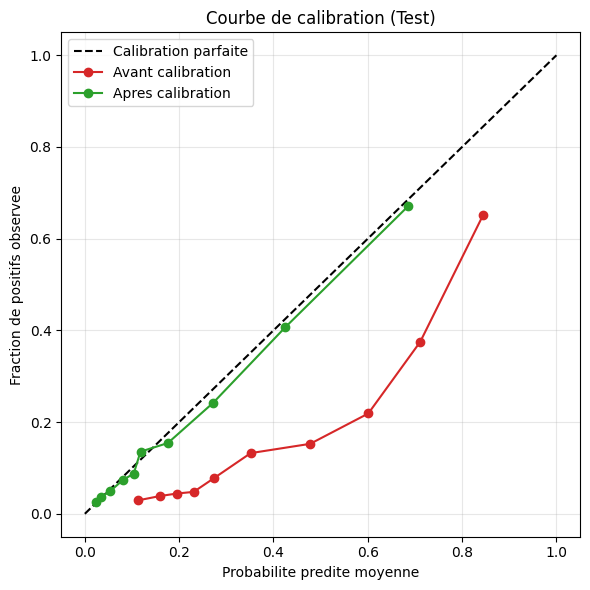

In [13]:
# CELLULE 13bis : CALIBRATION DES PROBABILITES (isotonic, sur val)
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve

calibrator = IsotonicRegression(out_of_bounds='clip')
calibrator.fit(y_val_prob, y_val)

y_test_prob_calibrated = calibrator.predict(y_test_prob)

print("\n Calibration isotonique ajustee sur le set de validation.")
print(f"AUC-ROC avant calibration (test) : {roc_auc_score(y_test, y_test_prob):.4f}")
print(f"AUC-ROC apres calibration (test) : {roc_auc_score(y_test, y_test_prob_calibrated):.4f}")
print("(l'AUC ne doit quasiment pas bouger - la calibration reordonne peu, "
      "elle reajuste l'echelle des probabilites)")

frac_pos_raw, mean_pred_raw = calibration_curve(y_test, y_test_prob, n_bins=10, strategy='quantile')
frac_pos_cal, mean_pred_cal = calibration_curve(y_test, y_test_prob_calibrated, n_bins=10, strategy='quantile')

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], 'k--', label='Calibration parfaite')
plt.plot(mean_pred_raw, frac_pos_raw, 'o-', label='Avant calibration', color='#d62728')
plt.plot(mean_pred_cal, frac_pos_cal, 'o-', label='Apres calibration', color='#2ca02c')
plt.xlabel('Probabilite predite moyenne')
plt.ylabel('Fraction de positifs observee')
plt.title('Courbe de calibration (Test)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Cellule 13 — Matrice de confusion (seuil officiel)

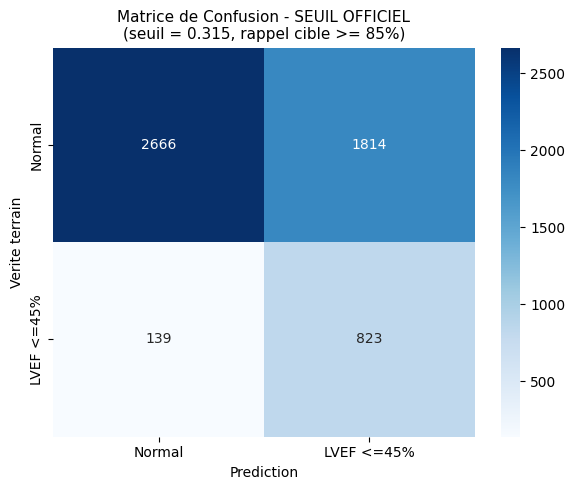

In [14]:
# CELLULE 13 : MATRICE DE CONFUSION (seuil officiel = rappel clinique cible)
best_pred = pred_recall  # seuil officiel du pipeline
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'LVEF <=45%'],
            yticklabels=['Normal', 'LVEF <=45%'])
plt.title(f"Matrice de Confusion - SEUIL OFFICIEL\n(seuil = {threshold_recall:.3f}, rappel cible >= {target_recall*100:.0f}%)", fontsize=11)
plt.ylabel('Verite terrain')
plt.xlabel('Prediction')
plt.tight_layout()
plt.show()


## Cellule 14 — Dashboard d'entraînement

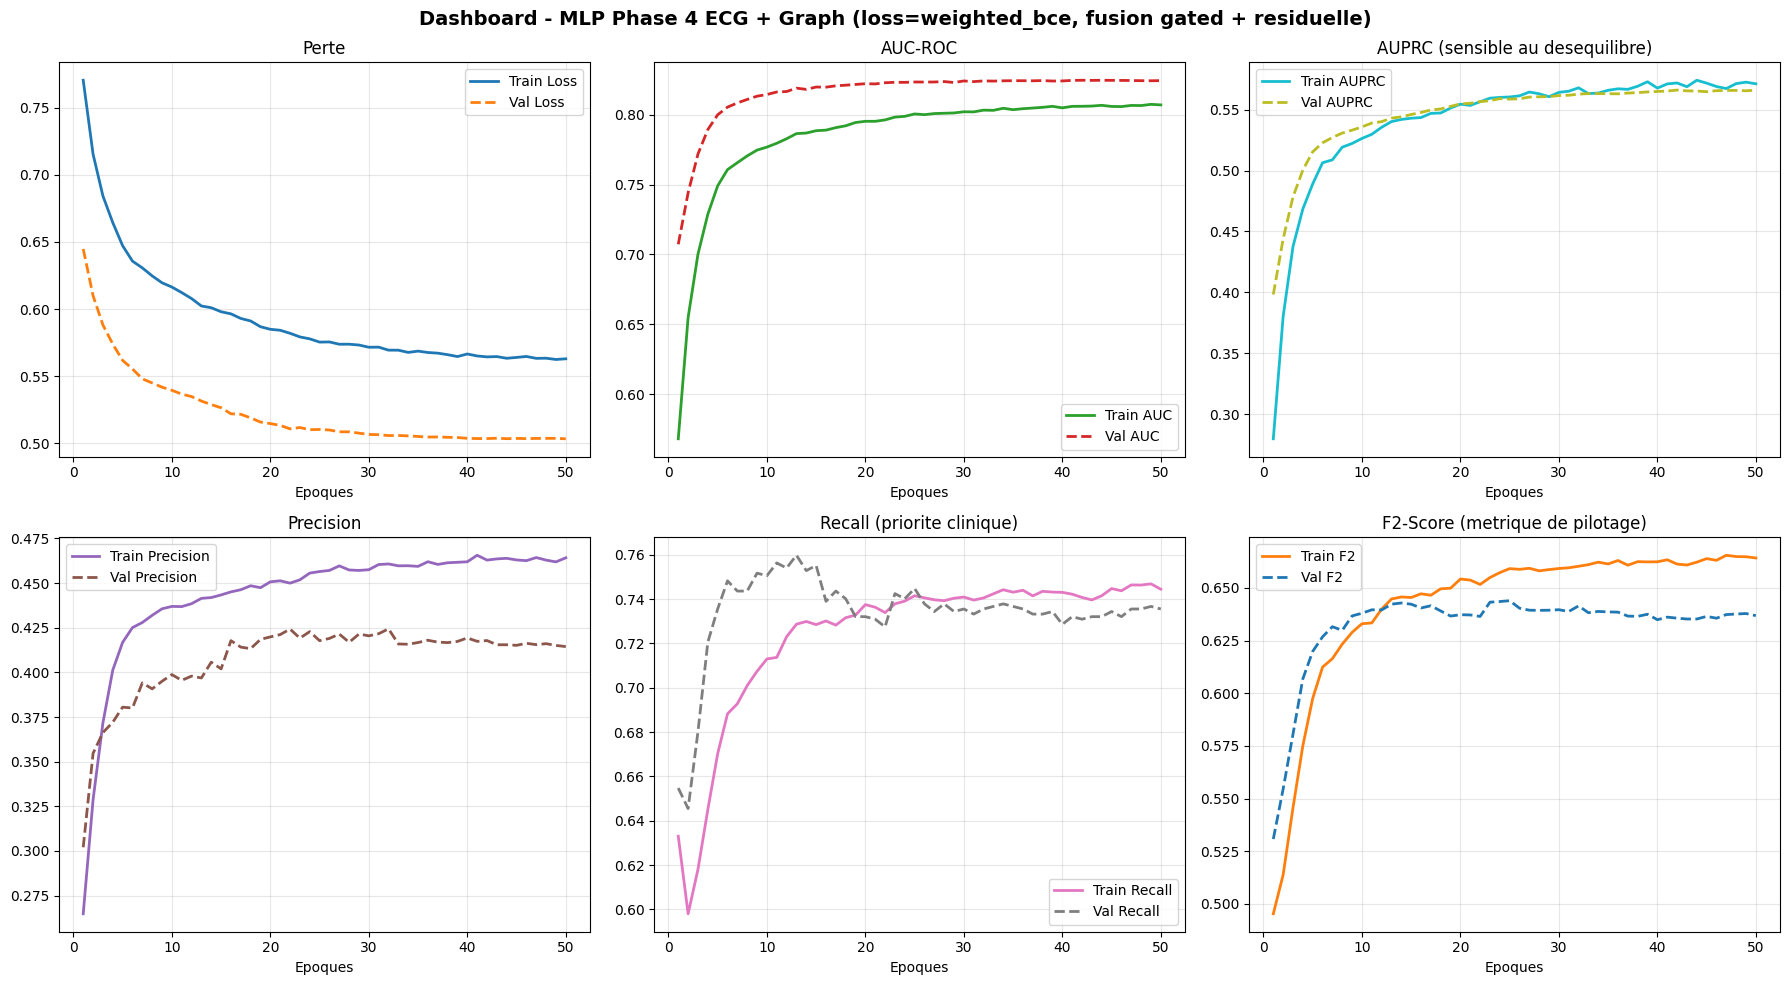


 Execution terminee.


In [15]:
# CELLULE 14 : DASHBOARD D'ENTRAINEMENT
epochs_range = range(1, len(history.history['loss']) + 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f"Dashboard - MLP Phase 4 ECG + Graph (loss={LOSS_TYPE}, fusion gated + residuelle)", fontsize=14, fontweight='bold')

axes[0,0].plot(epochs_range, history.history['loss'], label='Train Loss', color='#1f77b4', linewidth=2)
axes[0,0].plot(epochs_range, history.history['val_loss'], label='Val Loss', color='#ff7f0e', linestyle='--', linewidth=2)
axes[0,0].set_title('Perte'); axes[0,0].set_xlabel('Epoques'); axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(epochs_range, history.history['auc'], label='Train AUC', color='#2ca02c', linewidth=2)
axes[0,1].plot(epochs_range, history.history['val_auc'], label='Val AUC', color='#d62728', linestyle='--', linewidth=2)
axes[0,1].set_title('AUC-ROC'); axes[0,1].set_xlabel('Epoques'); axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

axes[0,2].plot(epochs_range, history.history['auprc'], label='Train AUPRC', color='#17becf', linewidth=2)
axes[0,2].plot(epochs_range, history.history['val_auprc'], label='Val AUPRC', color='#bcbd22', linestyle='--', linewidth=2)
axes[0,2].set_title('AUPRC (sensible au desequilibre)'); axes[0,2].set_xlabel('Epoques'); axes[0,2].legend(); axes[0,2].grid(True, alpha=0.3)

axes[1,0].plot(epochs_range, history.history['precision'], label='Train Precision', color='#9467bd', linewidth=2)
axes[1,0].plot(epochs_range, history.history['val_precision'], label='Val Precision', color='#8c564b', linestyle='--', linewidth=2)
axes[1,0].set_title('Precision'); axes[1,0].set_xlabel('Epoques'); axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(epochs_range, history.history['recall'], label='Train Recall', color='#e377c2', linewidth=2)
axes[1,1].plot(epochs_range, history.history['val_recall'], label='Val Recall', color='#7f7f7f', linestyle='--', linewidth=2)
axes[1,1].set_title('Recall (priorite clinique)'); axes[1,1].set_xlabel('Epoques'); axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

axes[1,2].plot(epochs_range, history.history['f2_score'], label='Train F2', color='#ff7f0e', linewidth=2)
axes[1,2].plot(epochs_range, history.history['val_f2_score'], label='Val F2', color='#1f77b4', linestyle='--', linewidth=2)
axes[1,2].set_title('F2-Score (metrique de pilotage)'); axes[1,2].set_xlabel('Epoques'); axes[1,2].legend(); axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Execution terminee.")


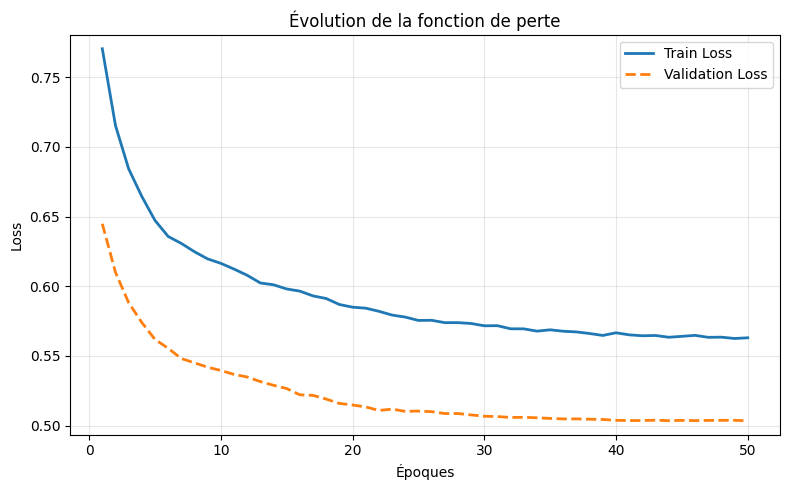

In [16]:
# ============================================================
# FIGURE 1 — COURBE COMPLÈTE DE LOSS
# ============================================================

plt.figure(figsize=(8, 5))

train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

plt.plot(
    epochs_range,
    train_loss,
    label="Train Loss",
    linewidth=2
)

plt.plot(
    epochs_range,
    val_loss,
    label="Validation Loss",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Époques")
plt.ylabel("Loss")
plt.title("Évolution de la fonction de perte")

plt.legend()
plt.grid(True, alpha=0.3)

# ------------------------------------------------------------
# Échelle Y resserrée mais couvrant TOUTES les époques
# ------------------------------------------------------------
y_min = min(min(train_loss), min(val_loss))
y_max = max(max(train_loss), max(val_loss))

# Petite marge uniquement
margin = 0.01

plt.ylim(
    y_min - margin,
    y_max + margin
)

plt.tight_layout()
plt.show()

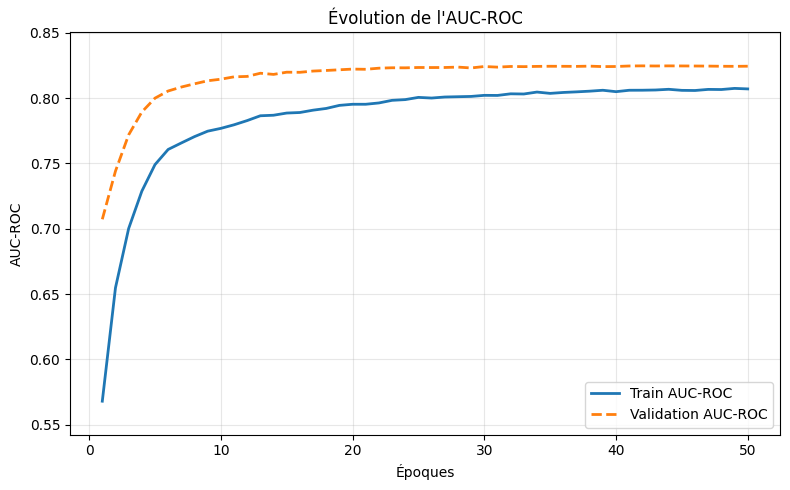

In [17]:
# ============================================================
# FIGURE 2 — ROC-AUC
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    history.history["auc"],
    label="Train AUC-ROC",
    linewidth=2
)

plt.plot(
    epochs_range,
    history.history["val_auc"],
    label="Validation AUC-ROC",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Époques")
plt.ylabel("AUC-ROC")
plt.title("Évolution de l'AUC-ROC")

plt.legend()
plt.grid(True, alpha=0.3)

# Échelle adaptée aux valeurs observées
auc_train = history.history["auc"]
auc_val = history.history["val_auc"]

auc_min = min(min(auc_train), min(auc_val))
auc_max = max(max(auc_train), max(auc_val))

margin = max((auc_max - auc_min) * 0.10, 0.01)

plt.ylim(
    max(0, auc_min - margin),
    min(1, auc_max + margin)
)

plt.tight_layout()
plt.show()

In [18]:
best_epoch_auc = np.argmax(history.history["val_auc"]) + 1
best_val_auc = np.max(history.history["val_auc"])

best_epoch_f2 = np.argmax(history.history["val_f2_score"]) + 1
best_val_f2 = np.max(history.history["val_f2_score"])

print("=" * 60)
print("MEILLEURES PERFORMANCES DE VALIDATION")
print("=" * 60)

print(
    f"Meilleure Val AUC : {best_val_auc:.4f} "
    f"(epoch {best_epoch_auc})"
)

print(
    f"Meilleur Val F2  : {best_val_f2:.4f} "
    f"(epoch {best_epoch_f2})"
)

MEILLEURES PERFORMANCES DE VALIDATION
Meilleure Val AUC : 0.8247 (epoch 42)
Meilleur Val F2  : 0.6440 (epoch 25)


## Cellule 15 — Fixer et sauvegarder le seuil officiel du pipeline

Documente la décision pour le mémoire et pour la Phase 5 (le score de risque alimentant le SSM devra utiliser ce même seuil pour toute décision binaire).

In [19]:
# CELLULE 15 : SAUVEGARDE DU SEUIL OFFICIEL DU PIPELINE
threshold_decision = {
    "seuil_retenu": float(threshold_recall),
    "strategie": "Rappel Clinique Cible",
    "objectif_rappel": target_recall,
    "justification": (
        "Contexte de depistage precoce : un faux positif entraine un examen de "
        "confirmation (echocardiographie), un faux negatif entraine un cas d'IC "
        "non detecte. Le rappel est donc priorise sur la precision."
    ),
    "metriques_test_au_seuil_retenu": {
        "precision": float(precision[np.where(thresholds >= threshold_recall)[0][0]]) if len(np.where(thresholds >= threshold_recall)[0]) > 0 else None,
        "recall": float(recall[np.where(thresholds >= threshold_recall)[0][0]]) if len(np.where(thresholds >= threshold_recall)[0]) > 0 else None,
        "auc_roc_test": float(roc_auc_score(y_test, y_test_prob)),
    },
    "seuils_alternatifs_comparatifs": {
        "f1_optimal": float(threshold_f1),
        "youden_j": float(threshold_youden),
        "precision_cible_60pct": float(threshold_prec),
    }
}

with open("seuil_officiel_pipeline.json", "w", encoding="utf-8") as f:
    json.dump(threshold_decision, f, indent=2, ensure_ascii=False)

print(" Decision de seuil sauvegardee : seuil_officiel_pipeline.json")
print(json.dumps(threshold_decision, indent=2, ensure_ascii=False))


 Decision de seuil sauvegardee : seuil_officiel_pipeline.json
{
  "seuil_retenu": 0.3145216703414917,
  "strategie": "Rappel Clinique Cible",
  "objectif_rappel": 0.85,
  "justification": "Contexte de depistage precoce : un faux positif entraine un examen de confirmation (echocardiographie), un faux negatif entraine un cas d'IC non detecte. Le rappel est donc priorise sur la precision.",
  "metriques_test_au_seuil_retenu": {
    "precision": 0.32625055334218683,
    "recall": 0.851039260969977,
    "auc_roc_test": 0.8206405925155925
  },
  "seuils_alternatifs_comparatifs": {
    "f1_optimal": 0.623277485370636,
    "youden_j": 0.4975419342517853,
    "precision_cible_60pct": 0.720450758934021
  }
}


In [20]:
# CELLULE FINALE : EMPAQUETAGE DES ARTEFACTS POUR LA PHASE 5
import joblib
import json
from sklearn.isotonic import IsotonicRegression

# Recrée le calibrateur sur le set de validation.
calibrator = IsotonicRegression(out_of_bounds="clip")
calibrator.fit(y_val_prob, y_val)

with open("seuil_officiel_pipeline.json", "r", encoding="utf-8") as f:
    threshold_info = json.load(f)

# Package Phase 4.
# Aucune donnée tabulaire/scaler tabulaire n'est nécessaire à l'inférence.
pipeline_config = {
    "calibrator": calibrator,
    "threshold_recall": threshold_info["seuil_retenu"],
    "threshold_f1": threshold_info["seuils_alternatifs_comparatifs"]["f1_optimal"],
    "threshold_youden": threshold_info["seuils_alternatifs_comparatifs"]["youden_j"],
    "target_recall": threshold_info["objectif_rappel"],
    "strategy": threshold_info["strategie"],

    "phase4_model_name": "best_mlp_phase4_ecg_graph_auc.keras",
    "phase4_inputs": {
        "ecg_embedding_dim": 128,
        "graph_embedding_dim": 128,
        "tabular_features_used": False
    },

    "export_date": pd.Timestamp.now().isoformat(),
}

joblib.dump(
    pipeline_config,
    "/kaggle/working/echonext_pipeline_config.pkl"
)

print("Artefact pipeline exporté : /kaggle/working/echonext_pipeline_config.pkl")
print("Phase 4 = ECG embedding 128D + Graph embedding 128D")
print("Features tabulaires utilisées en Phase 4 : NON")


Artefact pipeline exporté : /kaggle/working/echonext_pipeline_config.pkl
Phase 4 = ECG embedding 128D + Graph embedding 128D
Features tabulaires utilisées en Phase 4 : NON


## Cellule ablation — Focal Loss vs Weighted BCE
Entraine deux modeles identiques (meme seed, meme architecture, meme split) en ne faisant varier que la fonction de perte, puis compare AUC-ROC, AP, F2, et les metriques au seuil clinique officiel (rappel >= 85%).


RUN ABLATION : weighted_bce


2026-08-10 15:28:37.207205: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}
2026-08-10 15:28:57.324331: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

{'loss_type': 'weighted_bce', 'best_epoch_auc': 42, 'n_epochs_total': 50, 'val_auc': 0.8247227072715759, 'val_f2': 0.6439696550369263, 'test_auc_roc': 0.8206405925155925, 'test_ap': 0.5318448004754928, 'threshold_recall_85': 0.3145216703414917, 'test_recall_at_threshold': 0.8555093555093555, 'test_precision_at_threshold': 0.3120970800151687, 'test_specificity_at_threshold': 0.5950892857142858, 'test_fn': 139, 'test_fp': 1814, 'mean_pred_prob': 0.39564549922943115, 'actual_positive_rate': 0.17677324513046674}

RUN ABLATION : focal


2026-08-10 15:41:53.884733: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}
2026-08-10 15:59:52.544940: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

{'loss_type': 'focal', 'best_epoch_auc': 45, 'n_epochs_total': 72, 'val_auc': 0.8248401284217834, 'val_f2': 0.5757507085800171, 'test_auc_roc': 0.8211777453964955, 'test_ap': 0.5441700801736448, 'threshold_recall_85': 0.367498517036438, 'test_recall_at_threshold': 0.8482328482328483, 'test_precision_at_threshold': 0.3202511773940345, 'test_specificity_at_threshold': 0.6133928571428572, 'test_fn': 146, 'test_fp': 1732, 'mean_pred_prob': 0.38393333554267883, 'actual_positive_rate': 0.17677324513046674}

=== TABLEAU COMPARATIF ABLATION (Focal vs Weighted BCE) ===
loss_type                      weighted_bce        focal
best_epoch_auc                    42.000000    45.000000
n_epochs_total                    50.000000    72.000000
val_auc                            0.824723     0.824840
val_f2                             0.643970     0.575751
test_auc_roc                       0.820641     0.821178
test_ap                            0.531845     0.544170
threshold_recall_85               

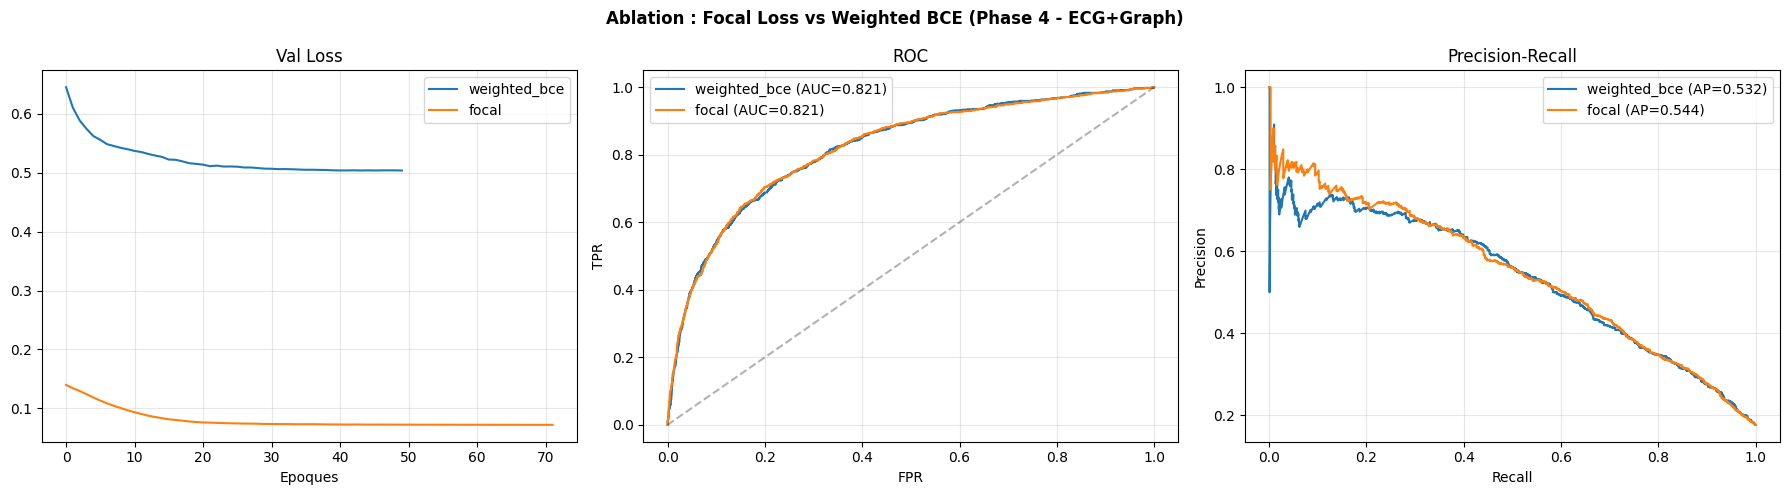


[OK] Resultats sauvegardes : ablation_focal_vs_weighted_bce.csv / .png


In [21]:
# ============================================================
# CELLULE ABLATION : FOCAL LOSS vs WEIGHTED BCE
# Compare les deux fonctions de perte a architecture/split/seed
# identiques. Ne modifie aucune variable des cellules precedentes
# (le modele final "model" reste celui entraine plus haut).
# ============================================================
import gc
from sklearn.metrics import average_precision_score

def get_loss(loss_type, class_weight_dict):
    if loss_type == "focal":
        return focal_loss(gamma=1.5, alpha=0.65)
    elif loss_type == "weighted_bce":
        return weighted_bce(class_weight_dict)
    else:
        raise ValueError(loss_type)

def run_experiment(loss_type, seed=SEED):
    # reset des seeds a CHAQUE run : sinon le 2e modele herite d'un
    # etat RNG different du 1er et la comparaison n'est plus fair
    tf.keras.backend.clear_session()
    random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)

    cw = compute_class_weight(y_train)
    loss_fn_ablation = get_loss(loss_type, cw)

    model_ablation = build_model(loss=loss_fn_ablation)

    model_path_f2  = f"best_mlp_phase4_{loss_type}_f2.keras"
    model_path_auc = f"best_mlp_phase4_{loss_type}_auc.keras"

    cb = [
        callbacks.EarlyStopping(monitor='val_f2_score', patience=PATIENCE,
                                 mode='max', restore_best_weights=True, verbose=0),
        callbacks.ModelCheckpoint(model_path_f2, monitor='val_f2_score',
                                   mode='max', save_best_only=True, verbose=0),
        callbacks.ModelCheckpoint(model_path_auc, monitor='val_auc',
                                   mode='max', save_best_only=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_f2_score', factor=0.5,
                                     patience=LR_PATIENCE, mode='max',
                                     min_lr=1e-7, verbose=0),
    ]

    hist = model_ablation.fit(
        x=[X_train_ecg, X_train_graph], y=y_train,
        validation_data=([X_val_ecg, X_val_graph], y_val),
        epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=cb, verbose=0
    )

    y_val_prob_ab  = model_ablation.predict([X_val_ecg, X_val_graph], verbose=0).ravel()
    y_test_prob_ab = model_ablation.predict([X_test_ecg, X_test_graph], verbose=0).ravel()

    # meme regle de seuil "rappel clinique cible >= 85%", recalculee sur VAL pour ce run
    prec_curve, rec_curve, thr = precision_recall_curve(y_val, y_val_prob_ab)
    target_recall = 0.85
    valid = np.where(rec_curve >= target_recall)[0]
    if len(valid) > 0:
        idx = valid[np.argmax(prec_curve[valid])]
        threshold_recall_ab = thr[idx] if idx < len(thr) else 0.5
    else:
        threshold_recall_ab = 0.5

    y_pred_ab = (y_test_prob_ab > threshold_recall_ab).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_ab).ravel()

    metrics = {
        "loss_type": loss_type,
        "best_epoch_auc": int(np.argmax(hist.history["val_auc"]) + 1),
        "n_epochs_total": len(hist.history["loss"]),
        "val_auc": float(np.max(hist.history["val_auc"])),
        "val_f2": float(np.max(hist.history["val_f2_score"])),
        "test_auc_roc": float(roc_auc_score(y_test, y_test_prob_ab)),
        "test_ap": float(average_precision_score(y_test, y_test_prob_ab)),
        "threshold_recall_85": float(threshold_recall_ab),
        "test_recall_at_threshold": float(tp / (tp + fn)) if (tp + fn) > 0 else 0.0,
        "test_precision_at_threshold": float(tp / (tp + fp)) if (tp + fp) > 0 else 0.0,
        "test_specificity_at_threshold": float(tn / (tn + fp)) if (tn + fp) > 0 else 0.0,
        "test_fn": int(fn), "test_fp": int(fp),
        "mean_pred_prob": float(np.mean(y_test_prob_ab)),
        "actual_positive_rate": float(np.mean(y_test)),
    }

    gc.collect()
    return hist, metrics, y_test_prob_ab

# --- Lancement des 2 runs ---
results_ablation = {}
probs_ablation = {}
for lt in ["weighted_bce", "focal"]:
    print(f"\n{'='*70}\nRUN ABLATION : {lt}\n{'='*70}")
    hist_ab, metr_ab, y_test_prob_ab = run_experiment(lt)
    results_ablation[lt] = {"history": hist_ab, "metrics": metr_ab}
    probs_ablation[lt] = y_test_prob_ab
    print(metr_ab)

# --- Tableau comparatif ---
df_ablation = pd.DataFrame(
    [results_ablation[lt]["metrics"] for lt in results_ablation]
).set_index("loss_type")
print("\n=== TABLEAU COMPARATIF ABLATION (Focal vs Weighted BCE) ===")
print(df_ablation.T)
df_ablation.to_csv("ablation_focal_vs_weighted_bce.csv")

# --- Comparaison visuelle ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for lt in results_ablation:
    axes[0].plot(results_ablation[lt]["history"].history["val_loss"], label=lt)
axes[0].set_title("Val Loss"); axes[0].set_xlabel("Epoques")
axes[0].legend(); axes[0].grid(alpha=0.3)

for lt in results_ablation:
    fpr, tpr, _ = roc_curve(y_test, probs_ablation[lt])
    axes[1].plot(fpr, tpr, label=f"{lt} (AUC={roc_auc_score(y_test, probs_ablation[lt]):.3f})")
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_title("ROC"); axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].legend(); axes[1].grid(alpha=0.3)

for lt in results_ablation:
    prec_c, rec_c, _ = precision_recall_curve(y_test, probs_ablation[lt])
    axes[2].plot(rec_c, prec_c, label=f"{lt} (AP={average_precision_score(y_test, probs_ablation[lt]):.3f})")
axes[2].set_title("Precision-Recall"); axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision")
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle("Ablation : Focal Loss vs Weighted BCE (Phase 4 - ECG+Graph)", fontweight="bold")
plt.tight_layout()
plt.savefig("ablation_focal_vs_weighted_bce.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n[OK] Resultats sauvegardes : ablation_focal_vs_weighted_bce.csv / .png")
